# Regressao de Consumo Eletrico: Dutch Energy

**Dataset:** [Energy consumption of the Netherlands](https://www.kaggle.com/datasets/lucabasa/dutch-energy)  
**Tarefa:** Regressao: prever o consumo eletrico anual agregado por faixa de CEP (kWh)  

O dataset contem dados de consumo de eletricidade e gas na Holanda, coletados por sete distribuidoras regionais (Enexis, Liander, Stedin, etc.). Cada registro agrega conexoes por faixa de CEP (minimo 10 conexoes para anonimizacao).

## Modelos comparados

| Tradicionais | Deep Learning |
|---|---|
| Linear Regression | MLP |
| Ridge / Lasso | |
| Random Forest | |
| XGBoost / LightGBM | |

## 1. Setup e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Setup concluido.")

Setup concluido.


## 2. Configuracao e download do dataset

No Google Colab, o dataset e baixado automaticamente via Kaggle API.  
Localmente, baixe do [Kaggle](https://www.kaggle.com/datasets/lucabasa/dutch-energy), extraia os CSVs e coloque na pasta `data/`.

In [2]:
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Download automatico no Colab
import os
if "COLAB_RELEASE_TAG" in os.environ and not list(DATA_DIR.glob("*electr*")):
    print("Colab detectado. Baixando dataset do Kaggle...")
    os.system("pip install -q kaggle")

    from google.colab import files
    if not Path("/root/.kaggle/kaggle.json").exists():
        print("Faca upload do kaggle.json (Kaggle > Settings > API > Create New Token):")
        uploaded = files.upload()
        os.makedirs("/root/.kaggle", exist_ok=True)
        for fn, content in uploaded.items():
            with open(f"/root/.kaggle/{fn}", "wb") as f:
                f.write(content)
        os.chmod("/root/.kaggle/kaggle.json", 0o600)

    TMP = Path("/tmp/dutch-energy")
    os.system(f"kaggle datasets download -d lucabasa/dutch-energy -p {TMP} --unzip")

    # Procurar CSVs de eletricidade em qualquer subpasta
    DATA_DIR.mkdir(exist_ok=True)
    import shutil
    found = list(TMP.rglob("*electr*.csv"))
    for f in found:
        shutil.move(str(f), str(DATA_DIR / f.name))
    print(f"Download concluido. {len(found)} arquivos de eletricidade em {DATA_DIR}")

    if not found:
        # Listar o que foi baixado para debug
        print("Conteudo baixado:")
        for p in sorted(TMP.rglob("*")):
            print(f"  {p}")
else:
    print(f"Buscando dados em {DATA_DIR.resolve()}")
    print(f"  Arquivos de eletricidade encontrados: {len(list(DATA_DIR.glob('*electr*')))}")

Buscando dados em C:\Users\guilh\Documents\Faculdade\IA\IA-RAG\notebooks\data
  Arquivos de eletricidade encontrados: 75


## 3. Carregamento dos dados

O dataset contem CSVs separados por tipo (eletricidade/gas) e por ano. Vamos carregar apenas os de eletricidade e concatenar tudo.

In [3]:
import re

elec_files = sorted(set(DATA_DIR.glob("*electr*")))

if not elec_files:
    raise FileNotFoundError(
        f"Nenhum CSV de eletricidade encontrado em {DATA_DIR.resolve()}. "
        "Baixe o dataset do Kaggle e extraia aqui."
    )

USE_COLS = [
    "net_manager", "purchase_area", "city", "num_connections",
    "delivery_perc", "perc_of_active_connections", "type_of_connection",
    "type_conn_perc", "annual_consume", "annual_consume_lowtarif_perc",
    "smartmeter_perc",
]

NUM_COLS = [
    "num_connections", "delivery_perc", "perc_of_active_connections",
    "type_conn_perc", "annual_consume", "annual_consume_lowtarif_perc",
    "smartmeter_perc",
]

frames = []
for fp in sorted(elec_files):
    header = pd.read_csv(fp, nrows=0).columns.tolist()
    cols = [c for c in USE_COLS if c in header]

    # Ler tudo como string para evitar erros de cast
    chunk = pd.read_csv(fp, usecols=cols, dtype=str, low_memory=False)

    # Converter colunas numericas (coerce transforma texto invalido em NaN)
    for col in NUM_COLS:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

    # Categoricas
    for col in ["net_manager", "purchase_area", "city", "type_of_connection"]:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype("category")

    match = re.search(r"(20\d{2})", fp.stem)
    if match:
        chunk["year"] = np.int16(int(match.group(1)))

    print(f"  {fp.name}: {len(chunk):>9,} registros")
    frames.append(chunk)

raw_df = pd.concat(frames, ignore_index=True)
del frames; gc.collect()
print(f"\nTotal: {len(raw_df):,} registros | Memoria: {raw_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
raw_df.head()

  coteq_electricity_2013.csv:     2,503 registros
  coteq_electricity_2014.csv:     2,503 registros
  coteq_electricity_2015.csv:     2,503 registros
  coteq_electricity_2016.csv:     2,503 registros
  coteq_electricity_2017.csv:     2,503 registros
  coteq_electricity_2018.csv:     2,503 registros
  coteq_electricity_2019.csv:     2,563 registros
  coteq_electricity_2020.csv:     2,575 registros
  endinet_electricity_01012011.csv:     5,743 registros
  endinet_electricity_01012012.csv:     5,795 registros
  endinet_electricity_01012013.csv:     5,883 registros
  endinet_electricity_01012014.csv:     4,546 registros
  endinet_electricity_01012015.csv:     4,550 registros
  endinet_electricity_01012016.csv:     4,565 registros
  enduriselectricity_01012013.csv:     9,559 registros
  enduriselectricity_01012014.csv:     9,572 registros
  enduriselectricity_01012015.csv:     9,609 registros
  enduriselectricity_01012016.csv:     9,646 registros
  enduriselectricity_01012017.csv:     9,699

,net_manager,purchase_area,city,num_connections,delivery_perc,perc_of_active_connections,type_conn_perc,type_of_connection,annual_consume,annual_consume_lowtarif_perc,smartmeter_perc,year
0,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,ENTER,19.0,89.470001,94.739998,89.0,1x35,4122.0,89.470001,0.0,2013
1,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,GOOR,37.0,100.000000,100.000000,86.0,1x35,1800.0,94.589996,0.0,2013
2,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,GOOR,16.0,100.000000,100.000000,100.0,1x35,1315.0,100.000000,0.0,2013
3,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,GOOR,25.0,92.000000,84.000000,44.0,1x35,6379.0,92.000000,0.0,2013
4,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,GOOR,14.0,85.709999,100.000000,36.0,1x35,4404.0,92.860001,0.0,2013


In [4]:
print("Colunas:", list(raw_df.columns))
print("\nTipos:")
print(raw_df.dtypes)
print("\nNulos:")
print(raw_df.isnull().sum())
print("\nDescritivas:")
raw_df.describe()

Colunas: ['net_manager', 'purchase_area', 'city', 'num_connections', 'delivery_perc', 'perc_of_active_connections', 'type_conn_perc', 'type_of_connection', 'annual_consume', 'annual_consume_lowtarif_perc', 'smartmeter_perc', 'year']

Tipos:
net_manager                         str
purchase_area                       str
city                                str
num_connections                 float32
delivery_perc                   float32
perc_of_active_connections      float32
type_conn_perc                  float32
type_of_connection                  str
annual_consume                  float32
annual_consume_lowtarif_perc    float32
smartmeter_perc                 float32
year                              int16
dtype: object

Nulos:
net_manager                      29224
purchase_area                   886657
city                                 0
num_connections                      7
delivery_perc                     2069
perc_of_active_connections        1487
type_conn_perc         

,num_connections,delivery_perc,perc_of_active_connections,type_conn_perc,annual_consume,annual_consume_lowtarif_perc,smartmeter_perc,year
count,4.077345e+06,4.075283e+06,4.075865e+06,3.884802e+06,4.077352e+06,4.064084e+06,4.064084e+06,4.077352e+06
mean,2.326049e+01,9.591370e+01,9.691261e+01,7.545778e+01,4.450214e+03,5.301489e+01,2.357910e+01,2.014785e+03
std,1.550751e+01,9.385684e+00,9.580210e+00,1.976434e+01,3.613797e+03,3.072666e+01,3.257335e+01,3.348562e+00
min,1.379000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.009000e+03
25%,1.500000e+01,9.545000e+01,1.000000e+02,5.900000e+01,2.677000e+03,2.857000e+01,0.000000e+00,2.012000e+03
50%,2.000000e+01,1.000000e+02,1.000000e+02,7.800000e+01,3.475000e+03,4.920000e+01,6.250000e+00,2.015000e+03
75%,2.600000e+01,1.000000e+02,1.000000e+02,9.400000e+01,4.680000e+03,8.261000e+01,3.636000e+01,2.018000e+03
max,1.330000e+03,1.000000e+02,1.000000e+02,1.000000e+02,4.299312e+05,1.000000e+02,1.000000e+02,2.020000e+03


## 4. Pre-processamento

Colunas esperadas:
- `net_manager`: distribuidora regional
- `purchase_area`: area de compra
- `street`, `zipcode_from`, `zipcode_to`, `city`: localizacao
- `num_connections`: numero de conexoes na faixa de CEP
- `delivery_perc`: percentual do consumo liquido
- `perc_of_active_connections`: percentual de conexoes ativas
- `type_of_connection`: tipo principal de conexao
- `type_conn_perc`: percentual do tipo principal
- `annual_consume`: consumo anual em kWh (variavel alvo)
- `annual_consume_lowtarif_perc`: percentual em horario de tarifa baixa
- `smartmeter_perc`: percentual de medidores inteligentes

In [5]:
TARGET = "annual_consume"

df = raw_df.copy()

if "year" in df.columns:
    print(f"Anos disponiveis: {sorted(df['year'].unique())}")
else:
    print("Coluna 'year' nao encontrada.")

# Remover registros sem consumo ou com consumo negativo
before = len(df)
df = df[df[TARGET].notna() & (df[TARGET] > 0)].copy()
print(f"Removidos {before - len(df)} registros sem consumo valido")

# Remover outliers extremos (acima do percentil 99.5)
q_high = df[TARGET].quantile(0.995)
before = len(df)
df = df[df[TARGET] <= q_high].copy()
print(f"Removidos {before - len(df)} outliers (>{q_high:.0f} kWh)")

print(f"\nDataset limpo: {len(df):,} registros")
del raw_df; gc.collect()
df[TARGET].describe()

Anos disponiveis: [np.int16(2009), np.int16(2010), np.int16(2011), np.int16(2012), np.int16(2013), np.int16(2014), np.int16(2015), np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2020)]
Removidos 1855 registros sem consumo valido
Removidos 20378 outliers (>24768 kWh)

Dataset limpo: 4,055,119 registros


count    4.055119e+06
mean     4.318705e+03
std      3.035512e+03
min      2.600000e-01
25%      2.673830e+03
50%      3.468000e+03
75%      4.650000e+03
max      2.476800e+04
Name: annual_consume, dtype: float64

## 5. Analise exploratoria (EDA)

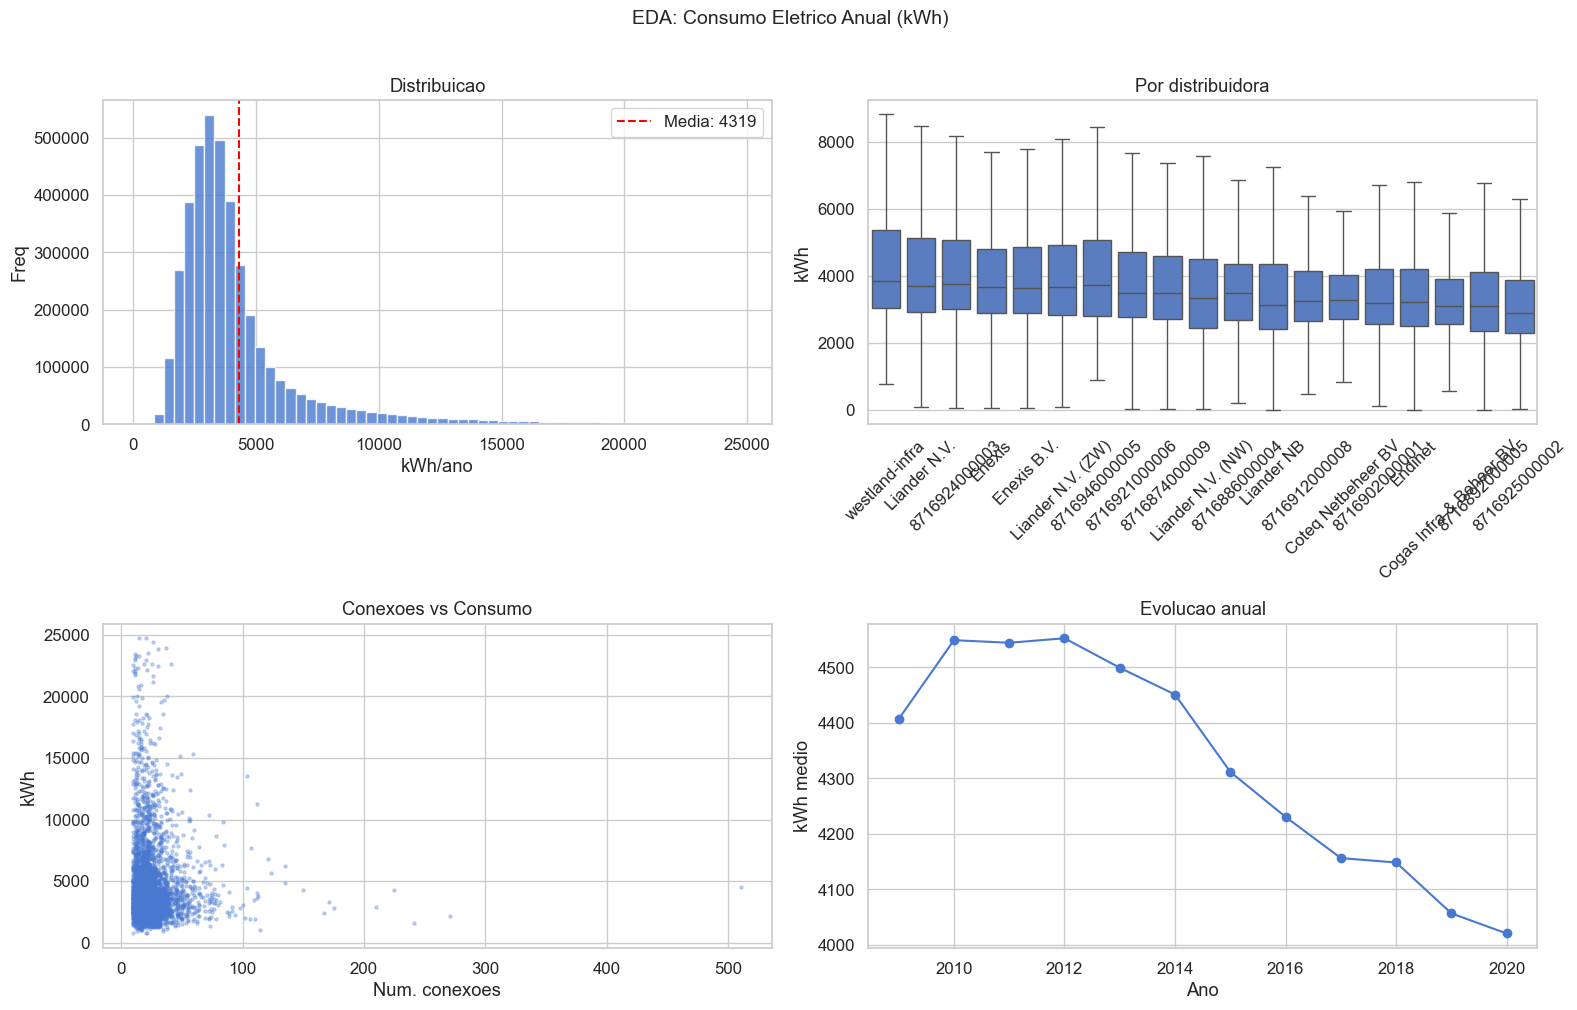

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("EDA: Consumo Eletrico Anual (kWh)", fontsize=14, y=1.01)

# Distribuicao do consumo
ax = axes[0, 0]
ax.hist(df[TARGET], bins=60, edgecolor="white", alpha=0.8)
m = df[TARGET].mean()
ax.axvline(m, color="red", ls="--", label=f"Media: {m:.0f}")
ax.set_xlabel("kWh/ano"); ax.set_ylabel("Freq"); ax.set_title("Distribuicao"); ax.legend()

# Consumo medio por distribuidora
ax = axes[0, 1]
if "net_manager" in df.columns:
    order = df.groupby("net_manager")[TARGET].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x="net_manager", y=TARGET, order=order, ax=ax, showfliers=False)
    ax.set_xlabel(""); ax.set_ylabel("kWh"); ax.set_title("Por distribuidora")
    ax.tick_params(axis="x", rotation=45)

# Consumo vs numero de conexoes
ax = axes[1, 0]
if "num_connections" in df.columns:
    sample = df.sample(min(5000, len(df)), random_state=SEED)
    ax.scatter(sample["num_connections"], sample[TARGET], alpha=0.3, s=5)
    ax.set_xlabel("Num. conexoes"); ax.set_ylabel("kWh"); ax.set_title("Conexoes vs Consumo")

# Evolucao por ano
ax = axes[1, 1]
if "year" in df.columns:
    yearly = df.groupby("year")[TARGET].mean()
    ax.plot(yearly.index, yearly.values, marker="o")
    ax.set_xlabel("Ano"); ax.set_ylabel("kWh medio"); ax.set_title("Evolucao anual")

plt.tight_layout()
plt.show()

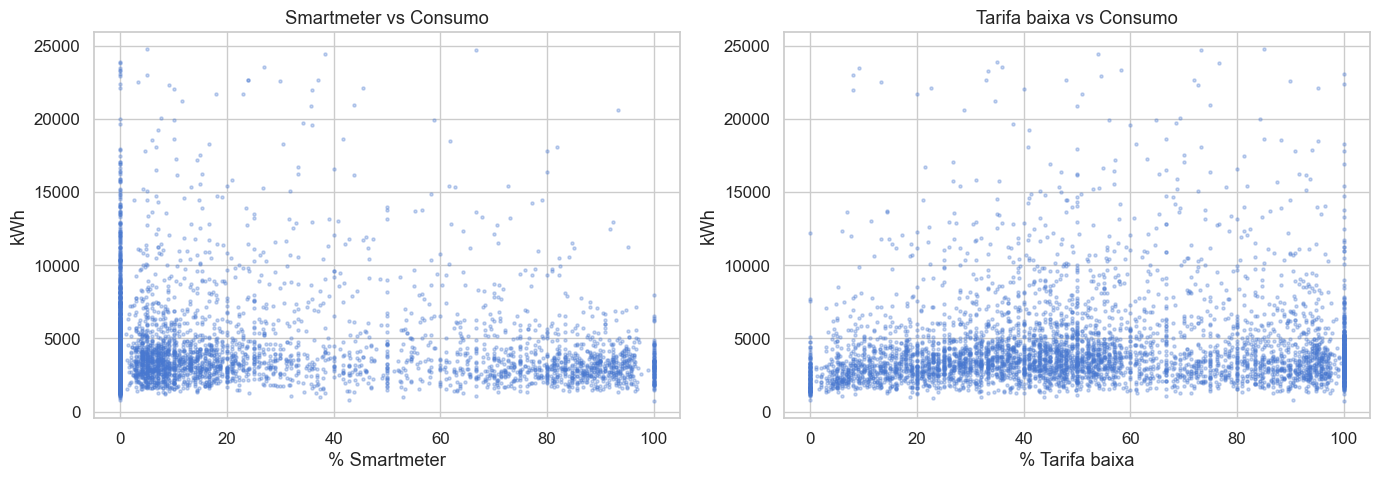

In [7]:
# Smartmeter vs consumo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "smartmeter_perc" in df.columns:
    ax = axes[0]
    sample = df.sample(min(5000, len(df)), random_state=SEED)
    ax.scatter(sample["smartmeter_perc"], sample[TARGET], alpha=0.3, s=5)
    ax.set_xlabel("% Smartmeter"); ax.set_ylabel("kWh"); ax.set_title("Smartmeter vs Consumo")

if "annual_consume_lowtarif_perc" in df.columns:
    ax = axes[1]
    sample = df.sample(min(5000, len(df)), random_state=SEED)
    ax.scatter(sample["annual_consume_lowtarif_perc"], sample[TARGET], alpha=0.3, s=5)
    ax.set_xlabel("% Tarifa baixa"); ax.set_ylabel("kWh"); ax.set_title("Tarifa baixa vs Consumo")

plt.tight_layout()
plt.show()

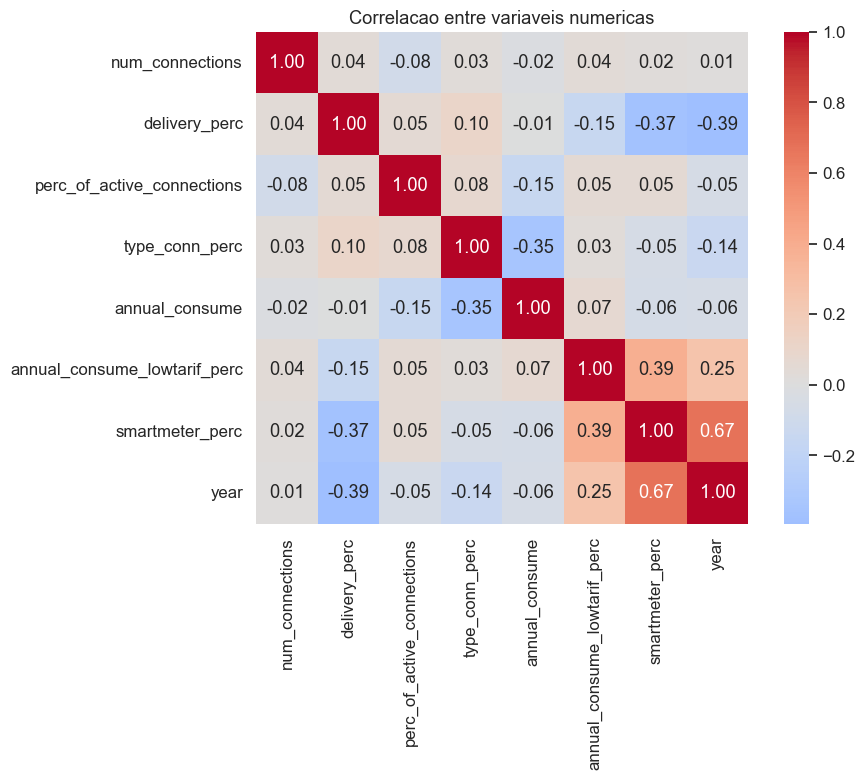

In [8]:
# Matriz de correlacao das variaveis numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlacao entre variaveis numericas")
    plt.tight_layout()
    plt.show()

## 6. Feature engineering

Estrategia:
- Normalizar o consumo por conexao (`consume_per_conn`) para reduzir a dependencia do tamanho do grupo
- Extrair a amperagem do `type_of_connection` (ex: "3x25" -> 75A) como proxy do porte da instalacao
- Usar **target encoding** em categoricas de alta cardinalidade (`city`, `purchase_area`) em vez de label encoding, que cria relacoes ordinais falsas
- Criar interacoes entre features relevantes

In [9]:
def parse_amperage(conn_str):
    """Extrai amperagem total de strings como '3x25' -> 75, '1x35' -> 35."""
    if pd.isna(conn_str) or conn_str == "nan":
        return np.nan
    m = re.match(r"(\d+)x(\d+)", str(conn_str).strip())
    if m:
        return int(m.group(1)) * int(m.group(2))
    return np.nan

def create_features(df):
    df = df.copy()

    # Amperagem a partir do type_of_connection
    if "type_of_connection" in df.columns:
        df["amperage"] = df["type_of_connection"].apply(parse_amperage).astype("float32")

    # Consumo por conexao (feature derivada chave)
    if "num_connections" in df.columns:
        df["consume_per_conn"] = (df[TARGET] / df["num_connections"].replace(0, np.nan)).astype("float32")

    # Interacao: amperagem * num_connections (capacidade total da area)
    if "amperage" in df.columns and "num_connections" in df.columns:
        df["total_capacity"] = (df["amperage"] * df["num_connections"]).astype("float32")

    # Proporcao de tarifa alta (complemento da baixa)
    if "annual_consume_lowtarif_perc" in df.columns:
        df["hightarif_perc"] = (100.0 - df["annual_consume_lowtarif_perc"]).astype("float32")

    # Target encoding para categoricas de alta cardinalidade
    # Usamos a media do target por categoria (calculada SOMENTE no train depois do split)
    # Aqui so preparamos as colunas; o encoding sera feito apos o split para evitar data leakage
    cat_cols_to_encode = ["city", "purchase_area", "net_manager"]
    for col in cat_cols_to_encode:
        if col not in df.columns:
            cat_cols_to_encode.remove(col)

    before = len(df)
    df.dropna(subset=[TARGET], inplace=True)
    print(f"  Registros apos limpeza: {len(df):,} (removidos {before - len(df)})")

    return df, cat_cols_to_encode

print("Feature Engineering...")
feat_df, CAT_COLS_TO_ENCODE = create_features(df)
del df; gc.collect()

print(f"  Shape: {feat_df.shape}")
print(f"  Novas colunas: amperage, consume_per_conn, total_capacity, hightarif_perc")
print(f"  Categoricas para target encoding: {CAT_COLS_TO_ENCODE}")
feat_df[["amperage", "consume_per_conn", "total_capacity"]].describe()

Feature Engineering...
  Registros apos limpeza: 4,055,119 (removidos 0)
  Shape: (4055119, 16)
  Novas colunas: amperage, consume_per_conn, total_capacity, hightarif_perc
  Categoricas para target encoding: ['city', 'purchase_area', 'net_manager']


,amperage,consume_per_conn,total_capacity
count,3.276143e+06,4.055112e+06,3.276143e+06
mean,4.561493e+01,2.279811e+02,1.073429e+03
std,2.198482e+01,2.031367e+02,9.428401e+02
min,6.000000e+00,1.368421e-02,4.826500e+01
25%,2.500000e+01,1.166923e+02,5.500000e+02
50%,3.500000e+01,1.742174e+02,8.250000e+02
75%,7.500000e+01,2.644667e+02,1.350000e+03
max,2.400000e+02,5.034341e+03,7.830000e+04


## 7. Selecao de features e split

In [10]:
# Colunas a excluir do modelo (strings brutas e target)
EXCLUDE = [
    TARGET, "street", "zipcode_from", "zipcode_to", "city",
    "net_manager", "purchase_area", "type_of_connection",
    "consume_per_conn",  # derivada do target, usada so para features abaixo
]

# Selecionar features numericas + as que vamos criar via target encoding
NUM_FEAT_COLS = [c for c in feat_df.columns if c not in EXCLUDE
                 and feat_df[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.int16]]

# Remover linhas com NaN nas features numericas essenciais
essential = [c for c in NUM_FEAT_COLS if c not in [f"{cat}_te" for cat in CAT_COLS_TO_ENCODE]]
model_df = feat_df[NUM_FEAT_COLS + [TARGET] + CAT_COLS_TO_ENCODE].dropna(subset=essential + [TARGET]).copy()
del feat_df; gc.collect()
print(f"Registros para modelagem: {len(model_df):,}")

# Split: 70/15/15
X_full = model_df.drop(columns=[TARGET])
y_full = model_df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_full, y_full, test_size=TEST_RATIO, random_state=SEED
)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=val_frac, random_state=SEED
)
del model_df, X_full, y_full, X_train_full, y_train_full; gc.collect()

# Target encoding: calcular media do target POR CATEGORIA somente no TRAIN
# Aplicar no val/test com fallback para media global (evita data leakage)
global_mean = y_train.mean()

for col in CAT_COLS_TO_ENCODE:
    if col in X_train.columns:
        te_map = X_train[[col]].copy()
        te_map["_target"] = y_train.values
        te_map = te_map.groupby(col)["_target"].mean()

        enc_col = f"{col}_te"
        X_train[enc_col] = X_train[col].map(te_map).fillna(global_mean).astype("float32")
        X_val[enc_col] = X_val[col].map(te_map).fillna(global_mean).astype("float32")
        X_test[enc_col] = X_test[col].map(te_map).fillna(global_mean).astype("float32")

# Agora dropar as colunas categoricas brutas
X_train = X_train.drop(columns=CAT_COLS_TO_ENCODE, errors="ignore")
X_val = X_val.drop(columns=CAT_COLS_TO_ENCODE, errors="ignore")
X_test = X_test.drop(columns=CAT_COLS_TO_ENCODE, errors="ignore")

FEAT_COLS = X_train.columns.tolist()

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"\nFeatures ({len(FEAT_COLS)}):")
for c in FEAT_COLS:
    print(f"  {c}")

# Escalar features
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xv_s = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)

Registros para modelagem: 3,179,496
Train: 2,225,646 | Val: 476,925 | Test: 476,925

Features (13):
  num_connections
  delivery_perc
  perc_of_active_connections
  type_conn_perc
  annual_consume_lowtarif_perc
  smartmeter_perc
  year
  amperage
  total_capacity
  hightarif_perc
  city_te
  purchase_area_te
  net_manager_te


## 8. Funcoes auxiliares e metricas

- MAE: erro absoluto medio (kWh)
- RMSE: penaliza erros grandes
- MAPE: erro percentual
- R2: proporcao da variancia explicada

In [11]:
def evaluate(yt, yp, name):
    return {
        "Modelo": name,
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAPE": mean_absolute_percentage_error(yt, yp) * 100,
        "R2": r2_score(yt, yp),
    }

def show(m):
    print(f"  {m['Modelo']:25s} MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  MAPE={m['MAPE']:.1f}%  R2={m['R2']:.4f}")

results = []
preds = {}

## 9. Modelos tradicionais

### 9.1 Baseline: media historica

In [12]:
p = np.full(len(y_test), y_train.mean())
r = evaluate(y_test, p, "Baseline (Media)")
results.append(r); preds["Baseline"] = p; show(r)

  Baseline (Media)          MAE=1896.9  RMSE=3026.0  MAPE=52.4%  R2=-0.0000


### 9.2 Regressao linear

In [13]:
m_lr = LinearRegression().fit(Xtr_s, y_train)
p = m_lr.predict(Xte_s)
r = evaluate(y_test, p, "Linear Regression")
results.append(r); preds["Linear"] = p; show(r)

  Linear Regression         MAE=1570.6  RMSE=2476.2  MAPE=41.0%  R2=0.3304


### 9.3 Ridge (L2)

In [14]:
m_ridge = Ridge(alpha=1.0, random_state=SEED).fit(Xtr_s, y_train)
p = m_ridge.predict(Xte_s)
r = evaluate(y_test, p, "Ridge")
results.append(r); preds["Ridge"] = p; show(r)

  Ridge                     MAE=1566.9  RMSE=2470.3  MAPE=40.9%  R2=0.3336


### 9.4 Lasso (L1)

In [15]:
m_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=SEED).fit(Xtr_s, y_train)
p = m_lasso.predict(Xte_s)
r = evaluate(y_test, p, "Lasso")
results.append(r); preds["Lasso"] = p; show(r)
print(f"  Coeficientes zerados: {(np.abs(m_lasso.coef_) < 1e-6).sum()}/{len(FEAT_COLS)}")

  Lasso                     MAE=1566.9  RMSE=2470.3  MAPE=40.9%  R2=0.3336
  Coeficientes zerados: 0/13


### 9.5 Random Forest

In [16]:
m_rf = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    random_state=SEED, n_jobs=-1
).fit(X_train, y_train)
p = m_rf.predict(X_test)
r = evaluate(y_test, p, "Random Forest")
results.append(r); preds["RF"] = p; show(r)

  Random Forest             MAE=1289.8  RMSE=2162.4  MAPE=32.4%  R2=0.4894


### 9.6 XGBoost

In [17]:
m_xgb = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=30, random_state=SEED, verbosity=0
).fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
p = m_xgb.predict(X_test)
r = evaluate(y_test, p, "XGBoost")
results.append(r); preds["XGBoost"] = p; show(r)

  XGBoost                   MAE=1255.6  RMSE=2103.0  MAPE=31.5%  R2=0.5170


### 9.7 LightGBM

In [18]:
m_lgb = LGBMRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbosity=-1, n_jobs=-1
).fit(X_train, y_train, eval_set=[(X_val, y_val)])
p = m_lgb.predict(X_test)
r = evaluate(y_test, p, "LightGBM")
results.append(r); preds["LightGBM"] = p; show(r)

  LightGBM                  MAE=1267.6  RMSE=2118.8  MAPE=31.7%  R2=0.5097


## 10. Deep Learning: MLP

Rede fully-connected: Dense(128) -> Dense(64) -> Dense(32) -> Dense(1)

In [ ]:
mlp = Sequential([
    Input(shape=(Xtr_s.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.1),
    Dense(1),
])
mlp.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
mlp.summary()

cbs = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
]

hist_mlp = mlp.fit(
    Xtr_s, y_train,
    validation_data=(Xv_s, y_val),
    epochs=100, batch_size=256,
    callbacks=cbs, verbose=1,
)

p_mlp = mlp.predict(Xte_s, verbose=0).ravel()
r = evaluate(y_test, p_mlp, "MLP")
results.append(r); preds["MLP"] = p_mlp; show(r)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
8694/8694 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 6699272.5000 - mae: 1629.9569 - val_loss: 4976111.0000 - val_mae: 1373.1865 - learning_rate: 0.0010
Epoch 2/100
8694/8694 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 5286835.0000 - mae: 1417.2397 - val_loss: 4827542.0000 - val_mae: 1334.9873 - learning_rate: 0.0010
Epoch 3/100
8694/8694 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 5183926.5000 - mae: 1394.7380 - val_loss: 4767460.5000 - val_mae: 1322.0463 - learning_rate: 0.0010
Epoch 4/100
8694/8694 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 5121644.5000 - mae: 1381.4653 - val_loss: 4734875.5000 - val_mae: 1319.0005 - learning_rate: 0.0010
Epoch 5/100
8694/8694 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 5082059.0000 - mae: 1371.9557 - val_loss: 4701533.0000 - val_mae: 1310.8065 - learning_rate: 0.0010
Epoch 6/100
8694/8694 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 5051396.0000 - mae: 1365.3307 - val_loss: 4674680.5000 - val_mae: 1303.1926 - learning_rate: 0.0010
Epoch 7/100
8694

## 11. Avaliacao final e comparacao

In [ ]:
res_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
res_df.index += 1
res_df.index.name = "Rank"
print("RANKING FINAL\n")
print(res_df.to_string())
res_df.to_csv(RESULTS_DIR / "model_comparison.csv")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparacao de Modelos: Teste", fontsize=14)
colors = sns.color_palette("viridis", len(res_df))

for ax, col, lab in zip(axes, ["MAE", "RMSE", "R2"], ["MAE (kWh)", "RMSE (kWh)", "R2"]):
    bars = ax.barh(res_df["Modelo"], res_df[col], color=colors)
    ax.set_xlabel(lab)
    ax.invert_yaxis()
    for b, v in zip(bars, res_df[col]):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2,
                f" {v:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Predicoes vs valores reais

In [ ]:
# Melhor modelo tradicional
best_name = res_df[
    ~res_df["Modelo"].isin(["Baseline (Media)", "MLP"])
].iloc[0]["Modelo"]
best_key = {
    "Linear Regression": "Linear", "Ridge": "Ridge", "Lasso": "Lasso",
    "Random Forest": "RF", "XGBoost": "XGBoost", "LightGBM": "LightGBM",
}.get(best_name, best_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Predicao vs Real (amostra do teste)", fontsize=14)

# Scatter: melhor tradicional
ax = axes[0]
ax.scatter(y_test.values, preds[best_key], alpha=0.2, s=5)
lim = [y_test.min(), y_test.max()]
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_xlabel("Real (kWh)"); ax.set_ylabel("Predito (kWh)")
ax.set_title(f"Melhor tradicional: {best_name}")

# Scatter: MLP
ax = axes[1]
ax.scatter(y_test.values, preds["MLP"], alpha=0.2, s=5, color="green")
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_xlabel("Real (kWh)"); ax.set_ylabel("Predito (kWh)")
ax.set_title("MLP")

plt.tight_layout()
plt.show()

### Curva de aprendizado: MLP

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_mlp.history["loss"], label="Train")
ax.plot(hist_mlp.history["val_loss"], label="Val")
ax.set_xlabel("Epoca"); ax.set_ylabel("MSE"); ax.set_title("MLP: Learning Curve")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Importancia de features

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

imp_rf = pd.Series(m_rf.feature_importances_, index=FEAT_COLS).nlargest(15)
imp_xgb = pd.Series(m_xgb.feature_importances_, index=FEAT_COLS).nlargest(15)

axes[0].barh(imp_rf.index[::-1], imp_rf.values[::-1])
axes[0].set_title("Random Forest: Top 15")

axes[1].barh(imp_xgb.index[::-1], imp_xgb.values[::-1])
axes[1].set_title("XGBoost: Top 15")

plt.tight_layout()
plt.show()

print("\nRidge: Top 10 coeficientes (|valor|):")
coefs = pd.Series(np.abs(m_ridge.coef_), index=FEAT_COLS).nlargest(10)
for f, v in coefs.items():
    print(f"  {f:<30s} {v:.4f}")

## 13. Distribuicao dos erros

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos do melhor modelo
residuals = y_test.values - preds[best_key]
ax = axes[0]
ax.hist(residuals, bins=50, edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", ls="--")
ax.set_xlabel("Residuo (kWh)"); ax.set_ylabel("Freq")
ax.set_title(f"Distribuicao dos residuos: {best_name}")

# QQ plot
from scipy import stats
ax = axes[1]
stats.probplot(residuals, plot=ax)
ax.set_title(f"QQ Plot: {best_name}")

plt.tight_layout()
plt.show()